In [ ]:
################################################# visualize nnUNet probability maps overlayed on CT slices #################################################

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
import ipywidgets as widgets

# ============================================================
# Utility
# ============================================================

def load_nnUNet_probs(npz_path):
    data = np.load(npz_path)
    probs = data["probabilities"]  # (C, X, Y, Z)
    fg_probs = probs[1]    
    print(np.where(np.any(fg_probs > 0.2, axis=(1, 2)))[0])        # second channel = foreground
    return fg_probs

def load_ct_volume(ct_path):
    ct = nib.load(str(ct_path)).get_fdata()
    ct = np.transpose(ct, (2, 1, 0))  # match probabilities orientation
    return ct

def window_ct_hu(ct, level=50, width=350):
    lower = level - width / 2.0
    upper = level + width / 2.0
    ct = np.clip(ct, lower, upper)
    ct = (ct - lower) / (upper - lower + 1e-6)
    return ct

# ============================================================
# Interactive Visualization
# ============================================================

def visualize_prob_overlay_slider(ct_volume, prob_volume, axis="axial", cmap_name="jet"):
    axis_map = {"axial":0, "coronal":1, "sagittal":2}
    ax = axis_map[axis]
    n_slices = ct_volume.shape[ax]

    def plot_slice(idx):
        if axis == "axial":
            ct_slice = ct_volume[idx, :, :]
            prob_slice = prob_volume[idx, :, :]
        elif axis == "coronal":
            ct_slice = ct_volume[:, idx, :]
            prob_slice = prob_volume[:, idx, :]
        elif axis == "sagittal":
            ct_slice = ct_volume[:, :, idx]
            prob_slice = prob_volume[:, :, idx]

        ct_img = window_ct_hu(ct_slice)

        plt.figure(figsize=(6,6))
        plt.imshow(ct_img, cmap="gray", origin="lower")
        plt.imshow(prob_slice, cmap=cmap_name, alpha=0.2, origin="lower", vmin=0, vmax=1)
        plt.colorbar(label="Foreground probability")
        plt.title(f"{axis.capitalize()} slice {idx}/{n_slices-1}")
        plt.axis("off")
        plt.show()

    slice_slider = widgets.IntSlider(
        value=n_slices//2, min=0, max=n_slices-1, step=1,
        description=f'{axis.capitalize()} slice', continuous_update=False
    )

    widgets.interact(plot_slice, idx=slice_slider)

# ============================================================
# Example usage
# ============================================================

if __name__ == "__main__":
    #46, 4, 125, 128, 134, 248, 286, 529, 93, 128
    uid = 339
    ct_path = f"/data/colon_cancer/CC_Detection/raw_data/Dataset107_CC/imagesTs/{uid}_0000.nii.gz"
    npz_path = f"/data/colon_cancer/CC_Detection/raw_data/Dataset107_CC/predictionsTs_cascade/{uid}.npz"

    ct = load_ct_volume(ct_path)
    fg_probs = load_nnUNet_probs(npz_path)

    visualize_prob_overlay_slider(ct, fg_probs, axis="axial")


In [7]:
########################################################### visualize one sample from the dataset with its label ################################


from matplotlib.colors import ListedColormap
import pandas as pd 
# ============================
# Utility Functions
# ============================

def load_volume(path):
    """Load a 3D volume from NIfTI (.nii.gz), NPZ, or NPY format."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    if path.suffix == ".npy":
        return np.load(path)
    elif path.suffix == ".npz":
        data = np.load(path)
        key = list(data.keys())[0]
        return data[key]
    elif path.suffix in [".nii", ".gz"]:
        return nib.load(str(path)).get_fdata()
    else:
        raise ValueError(f"Unsupported format: {path.suffix}")


def window_ct_hu(ct_hu, level=50, width=350):
    """Window the CT image for visualization."""
    lower, upper = level - width / 2.0, level + width / 2.0
    ct_clipped = np.clip(ct_hu, lower, upper)
    return (ct_clipped - lower) / (upper - lower + 1e-6)


def build_label_overlay(label_slice):
    """Return label colormap for segmentation overlay."""
    unique_labels = np.unique(label_slice)
    if np.array_equal(unique_labels, [0]) or np.array_equal(unique_labels, [0, 1]):
        cmap = ListedColormap([[0,0,0,0], [1,0,0,0.45]])  # red overlay
        return label_slice.astype(np.int32), cmap, (0, 1)
    colors = [[0, 0, 0, 0]]
    rng = np.random.default_rng(42)
    for _ in range(int(unique_labels.max())):
        colors.append([*rng.random(3), 0.45])
    cmap = ListedColormap(colors)
    return label_slice.astype(np.int32), cmap, (0, int(unique_labels.max()))


def get_slice(volume, axis, idx):
    """Extract a 2D slice along the chosen axis."""
    if axis == "axial":
        return volume[:, :, idx]
    elif axis == "coronal":
        return volume[:, idx, :]
    elif axis == "sagittal":
        return volume[idx, :, :]
    else:
        raise ValueError(f"Invalid axis: {axis}. Must be 'axial', 'coronal', or 'sagittal'.")


# ============================
# Main Visualization Function
# ============================

def visualize_case(ct_path, label_path, uid, target, axis="axial", save_dir=None,
                   window_level=50, window_width=350, save_all_slices=False):
    """Visualize a single case interactively, optionally saving overlays."""
    ct = load_volume(ct_path)
    label = load_volume(label_path)
    assert ct.shape == label.shape, f"Shape mismatch for {uid}: {ct.shape} vs {label.shape}"

    axis_to_dim = {"axial": 2, "coronal": 1, "sagittal": 0}
    n_slices = ct.shape[axis_to_dim[axis]]

    out_uid_dir = None
    if save_all_slices and save_dir:
        out_uid_dir = Path(save_dir) / str(uid)
        out_uid_dir.mkdir(parents=True, exist_ok=True)

    def plot_slice(idx):
        ct_slice = get_slice(ct, axis, idx)
        label_slice = get_slice(label, axis, idx)
        ct_img = window_ct_hu(ct_slice, window_level, window_width)
        lab_for_plot, lab_cmap, lab_vminmax = build_label_overlay(label_slice)

        plt.figure(figsize=(6, 6))
        plt.imshow(ct_img.T, cmap="gray", origin="lower")
        plt.imshow(lab_for_plot.T, cmap=lab_cmap, origin="lower",
                   vmin=lab_vminmax[0], vmax=lab_vminmax[1])
        plt.axis("off")
        plt.title(f"UID {uid} | Class: {target} | {axis.capitalize()} slice {idx}/{n_slices}")
        plt.tight_layout()

        if out_uid_dir:
            out_path = out_uid_dir / f"{axis}_slice{idx:03d}.png"
            plt.savefig(out_path, bbox_inches='tight')
            plt.close()
        else:
            plt.show()

    # Interactive slider
    slice_slider = widgets.IntSlider(
        value=n_slices // 2,
        min=0,
        max=n_slices - 1,
        step=1,
        description=f'UID {uid}',
        continuous_update=False
    )

    widgets.interact(plot_slice, idx=slice_slider)

    # Optionally save all slices automatically
    if save_all_slices and out_uid_dir:
        print(f"Saving all slices for UID {uid} → {out_uid_dir}")
        for i in range(n_slices):
            plot_slice(i)


def visualize_dataset(uids, img_root, label_root, axis="axial", save_dir=None, save_all_slices=False):
    """Visualize multiple UIDs."""
    img_root, label_root = Path(img_root), Path(label_root)
    df = pd.read_csv("/data/colon_cancer/CC_Detection/raw_data/Dataset100_CC/splits.csv")
    for uid in uids:
        # try naming patterns
        possible_names = [
            f"{uid}.nii.gz",f"{uid:03d}.nii.gz", f"{uid}_0000.nii.gz", f"{uid:03d}_0000.nii.gz",
            f"colon_{uid:03d}.nii.gz", f"{uid}.npy", f"{uid}.npz"
        ]
        
        
        img_path = next((img_root / n for n in possible_names if (img_root / n).exists()), None)
        label_path = next((label_root / n for n in possible_names if (label_root / n).exists()), None)
        print(img_path, label_path)
        if img_path is None or label_path is None:
            print(f"Skipping UID {uid}: missing image or label")
            continue

        row = df[df["UID"] == uid]
        target = row["target"].values[0]
        if target == 0:
            target = "div"
        else:
            target = "cc"

        visualize_case(img_path, label_path, uid, axis=axis, target=target,
                       save_dir=save_dir, save_all_slices=save_all_slices)


# ============================
# Example usage
# ============================

if __name__ == "__main__":
    uids = [108]
    img_root = "/data/colon_cancer/CC_Detection/raw_data/Dataset100_CC/imagesTr"
    label_root = "/data/colon_cancer/CC_Detection/raw_data/Dataset100_CC/labelsTr"
    
    save_dir = "/data/benchaaben/ColonCancerDetection/debug_notebooks/output_plot"

    visualize_dataset(uids, img_root, label_root,
                      axis="axial", save_dir=save_dir, save_all_slices=False)
    


    

/data/colon_cancer/CC_Detection/raw_data/Dataset100_CC/imagesTr/108_0000.nii.gz /data/colon_cancer/CC_Detection/raw_data/Dataset100_CC/labelsTr/108.nii.gz


NameError: name 'nib' is not defined

In [ ]:
###################################### generate shapes statistics from pkl. files generated by the segmentation model #####################################
import pickle
import json

def analyze_pkl_folder(pkl_folder: str, output_json: str, output_csv: str = None):
    """
    Analyze a folder of .pkl files containing dictionaries of properties.
    Computes mean, median, min, max, 10th and 90th percentiles per dimension for each property.
    Optionally saves all individual values to a CSV for histogram plotting.
    """
    pkl_folder = Path(pkl_folder)
    if not pkl_folder.exists():
        raise FileNotFoundError(f"Folder not found: {pkl_folder}")

    # Initialize storage
    properties = {
        "shape_before_cropping": [],
        "shape_after_crop_before_resampling": [],
        "shape_after_resampling": [],
        "spacing": []
    }

    # Iterate over .pkl files
    for pkl_file in pkl_folder.glob("*.pkl"):
        with open(pkl_file, "rb") as f:
            data = pickle.load(f)

        for key in properties.keys():
            if key in data:
                properties[key].append(np.array(data[key]))

    # Helper to compute statistics
    def compute_stats(array_list):
        arr = np.stack(array_list, axis=0)
        stats = {
            "mean_shape": np.mean(arr, axis=0).tolist(),
            "median_shape": np.median(arr, axis=0).tolist(),
            "min_shape": np.min(arr, axis=0).tolist(),
            "max_shape": np.max(arr, axis=0).tolist(),
            "10pct_shape": np.percentile(arr, 10, axis=0).tolist(),
            "90pct_shape": np.percentile(arr, 90, axis=0).tolist()
        }
        return stats

    # Compute stats for each property
    results = {key: compute_stats(values) if values else {} for key, values in properties.items()}

    # Save JSON
    with open(output_json, "w") as f:
        json.dump(results, f, indent=4)
    print(f"Summary statistics saved to {output_json}")

    # Save raw values for histogram plotting if requested
    if output_csv:
        all_data = {}
        for key, values in properties.items():
            all_data[key] = [v.tolist() for v in values]  # convert arrays to lists
        # Convert to a DataFrame for easier plotting
        df = pd.DataFrame({k: pd.Series(v) for k, v in all_data.items()})
        df.to_csv(output_csv, index=False)
        print(f"All individual values saved to {output_csv}")


# Example usage:
# analyze_pkl_folder(
#     pkl_folder="/data/benchaaben/ColonCancerDetection/stats_pkl",
#     output_json="dataset_stats.json",
#     output_csv="dataset_stats_raw.csv"
# )


In [ ]:
import ast

def parse_numeric_tuple_or_list(s):
    """
    Convert a string like '(1.0, 1.0, 1.5)' or '[1.0, 1.0, 1.5]' to a numpy array of floats.
    """
    if isinstance(s, str):
        try:
            t = ast.literal_eval(s)
            return np.array(t, dtype=float)
        except:
            raise ValueError(f"Cannot parse {s} as a numeric tuple/list")
    return np.array(s, dtype=float)

def plot_metric_histogram(csv_path, metric_column="original_shape", percentiles=(10, 90)):
    """
    Plots histograms for a given numeric metric column from a CSV.
    Supports columns with tuple/list-like entries (e.g., spacing or shapes) or single numeric values.
    """
    df = pd.read_csv(csv_path)

    # Check if the first value looks like a tuple or list
    sample_val = df[metric_column].iloc[0]
    if isinstance(sample_val, str) and (sample_val.startswith("(") or sample_val.startswith("[")):
        df[metric_column] = df[metric_column].apply(parse_numeric_tuple_or_list)
        values = np.stack(df[metric_column].values)  # shape (N, D)
        axis_labels = [f"dim {i}" for i in range(values.shape[1])]
    else:
        # Single numeric column
        values = df[metric_column].to_numpy(dtype=float).reshape(-1, 1)
        axis_labels = [metric_column]

    # Plot histograms
    fig, axs = plt.subplots(1, values.shape[1], figsize=(5 * values.shape[1], 4))
    if values.shape[1] == 1:
        axs = [axs]

    for i, ax in enumerate(axs):
        vals = values[:, i]
        mean_val = np.mean(vals)
        median_val = np.median(vals)
        min_val = np.min(vals)
        max_val = np.max(vals)
        p_low, p_high = np.percentile(vals, percentiles)

        ax.hist(vals, bins=20, color="lightcoral", edgecolor="black", alpha=0.7)
        ax.axvline(mean_val, color="orange", linestyle="--", label=f"Mean: {mean_val:.2f}")
        ax.axvline(median_val, color="red", linestyle="-.", label=f"Median: {median_val:.2f}")
        ax.axvline(min_val, color="green", linestyle=":", label=f"Min: {min_val:.2f}")
        ax.axvline(max_val, color="purple", linestyle=":", label=f"Max: {max_val:.2f}")
        ax.axvline(p_low, color="gray", linestyle="--", label=f"{percentiles[0]}th: {p_low:.2f}")
        ax.axvline(p_high, color="gray", linestyle="--", label=f"{percentiles[1]}th: {p_high:.2f}")

        ax.set_title(f" - {axis_labels[i]}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    #plt.suptitle(f"Distribution of the CT spacial dimensions after 1 mm isotropic resampling", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


plot_metric_histogram("/data/colon_cancer/CC_Detection/pp_data/Dataset107_CC/resampling_metadata_Tr.csv", metric_column="resampled_size")
#plot_metric_histogram("/data/colon_cancer/CC_Detection/pp_data/Dataset107_CC/cropping_metadata_Tr.csv", metric_column="original_shape")
#plot_metric_histogram("/data/colon_cancer/CC_Detection/pp_data/Dataset107_CC/cropping_metadata_Tr.csv", metric_column="cropped_shape")

Matched files: 20

=== Global Dice ===
N      : 20
Mean   : 0.522
Median : 0.605
Q1/Q3  : 0.386 / 0.697
Min/Max: 0.041 / 0.883

=== Category = bad ===
N      : 5
Mean   : 0.161
Median : 0.166
Q1/Q3  : 0.162 / 0.168
Min/Max: 0.041 / 0.267

=== Category = medium ===
N      : 11
Mean   : 0.584
Median : 0.606
Q1/Q3  : 0.536 / 0.619
Min/Max: 0.425 / 0.699

=== Category = good ===
N      : 4
Mean   : 0.805
Median : 0.791
Q1/Q3  : 0.780 / 0.816
Min/Max: 0.756 / 0.883

=== Class 0 ===
N      : 9
Mean   : 0.423
Median : 0.476
Q1/Q3  : 0.168 / 0.606
Min/Max: 0.041 / 0.699

=== Class 1 ===
N      : 11
Mean   : 0.604
Median : 0.607
Q1/Q3  : 0.540 / 0.772
Min/Max: 0.162 / 0.883


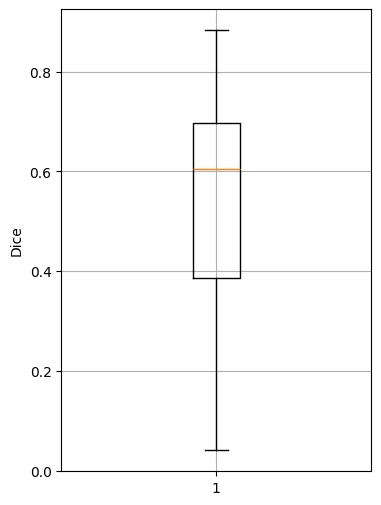

/tmp/ipykernel_1789060/3551055273.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cat_data, labels=["bad", "medium", "good"])


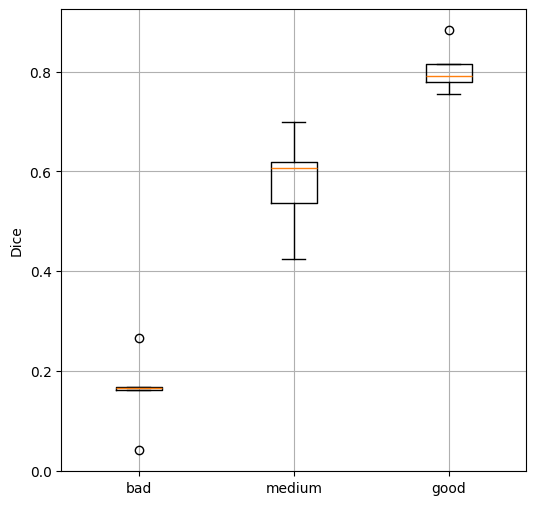

/tmp/ipykernel_1789060/3551055273.py:115: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(class_data, labels=[f"Class {c}" for c in classes])


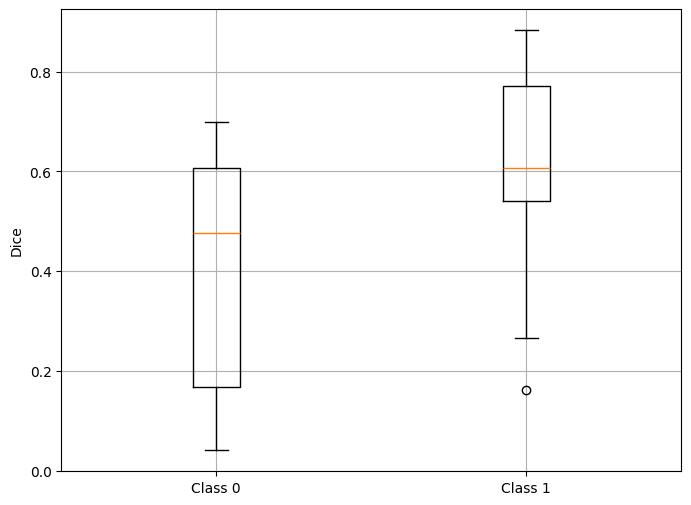

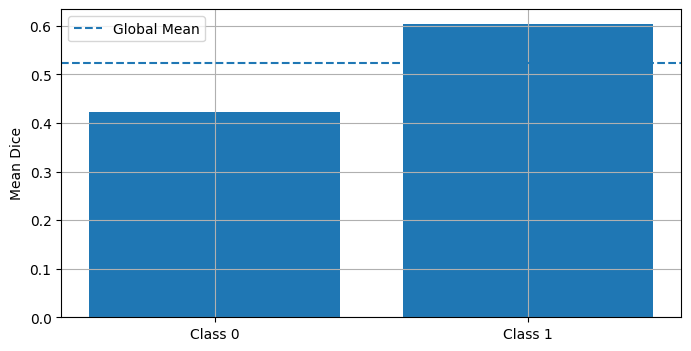

In [6]:
############################################### Post-process Dice results and generate statistics and plots ###############################################
from pathlib import Path
import json 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
# =============================
# Paths
# =============================
json_path = Path("/data/benchaaben/DINOv2-3D-Med/dice_results_orig.json")
csv_path  = Path("/data/colon_cancer/CC_Detection/raw_data/Dataset100_CC/splits.csv")  # <-- change

# =============================
# Load data
# =============================
with open(json_path, "r") as f:
    results = json.load(f)

per_file = results["per_file"]

df = pd.read_csv(csv_path)
df["UID"] = df["UID"].astype(str)

# =============================
# Build Dice table
# =============================
rows = []

for fname, v in per_file.items():
    uid = fname.replace(".nii.gz", "")
    dice = v["dice"]
    category = v["category"]

    match = df[df["UID"] == uid]
    if len(match) == 0:
        continue

    target = int(match.iloc[0]["target"])

    rows.append({
        "uid": uid,
        "dice": dice,
        "category": category,
        "class": target
    })

dice_df = pd.DataFrame(rows)

print(f"Matched files: {len(dice_df)}")

# =============================
# Statistics helpers
# =============================
def print_stats(name, values):
    values = np.array(values)
    print(f"\n=== {name} ===")
    print(f"N      : {len(values)}")
    print(f"Mean   : {values.mean():.3f}")
    print(f"Median : {np.median(values):.3f}")
    print(f"Q1/Q3  : {np.percentile(values,25):.3f} / {np.percentile(values,75):.3f}")
    print(f"Min/Max: {values.min():.3f} / {values.max():.3f}")

# =============================
# 1. Global statistics
# =============================
print_stats("Global Dice", dice_df["dice"])

# =============================
# 2. Per category statistics
# =============================
for cat in ["bad", "medium", "good"]:
    vals = dice_df[dice_df["category"] == cat]["dice"]
    print_stats(f"Category = {cat}", vals)

# =============================
# 3. Per class statistics
# =============================
for cls in sorted(dice_df["class"].unique()):
    vals = dice_df[dice_df["class"] == cls]["dice"]
    print_stats(f"Class {cls}", vals)

# =============================
# Plotting
# =============================

# ---------- Plot 1: Global ----------
plt.figure(figsize=(4,6))
plt.boxplot(dice_df["dice"], vert=True)
plt.ylabel("Dice")
#plt.title("Global Dice Distribution")
plt.grid(True)
plt.show()

# ---------- Plot 2: By category ----------
cat_data = [
    dice_df[dice_df["category"] == c]["dice"]
    for c in ["bad", "medium", "good"]
]

plt.figure(figsize=(6,6))
plt.boxplot(cat_data, labels=["bad", "medium", "good"])
plt.ylabel("Dice")
#plt.title("Dice Distribution by Category")
plt.grid(True)
plt.show()

# ---------- Plot 3: Per class ----------
classes = sorted(dice_df["class"].unique())
class_data = [
    dice_df[dice_df["class"] == c]["dice"]
    for c in classes
]

plt.figure(figsize=(8,6))
plt.boxplot(class_data, labels=[f"Class {c}" for c in classes])
plt.ylabel("Dice")
#plt.title("Dice Distribution per Class")
plt.grid(True)
plt.show()

# ---------- Plot 4: Aggregated vs Per-Class Mean ----------
means = [dice_df[dice_df["class"] == c]["dice"].mean() for c in classes]

plt.figure(figsize=(8,4))
plt.bar([f"Class {c}" for c in classes], means)
plt.axhline(dice_df["dice"].mean(), linestyle="--", label="Global Mean")
plt.ylabel("Mean Dice")
#plt.title("Mean Dice per Class vs Global")
plt.legend()
plt.grid(True)
plt.show()



Loaded 20 cases

Class distribution:
target
1    11
0     9
Name: count, dtype: int64

=== Global Dice ===
N      : 20
Mean   : 0.522
Median : 0.605
Q1/Q3  : 0.386 / 0.697
Min/Max: 0.041 / 0.883

=== Class 0 — Dice ===
N      : 9
Mean   : 0.423
Median : 0.476
Q1/Q3  : 0.168 / 0.606
Min/Max: 0.041 / 0.699

=== Class 1 — Dice ===
N      : 11
Mean   : 0.604
Median : 0.607
Q1/Q3  : 0.540 / 0.772
Min/Max: 0.162 / 0.883

=== Global Precision ===
N      : 20
Mean   : 0.651
Median : 0.779
Q1/Q3  : 0.602 / 0.833
Min/Max: 0.157 / 0.911

=== Class 0 — Precision ===
N      : 9
Mean   : 0.678
Median : 0.810
Q1/Q3  : 0.665 / 0.842
Min/Max: 0.157 / 0.911

=== Class 1 — Precision ===
N      : 11
Mean   : 0.629
Median : 0.696
Q1/Q3  : 0.563 / 0.829
Min/Max: 0.173 / 0.846

=== Global Recall ===
N      : 20
Mean   : 0.486
Median : 0.523
Q1/Q3  : 0.324 / 0.622
Min/Max: 0.024 / 0.923

=== Class 0 — Recall ===
N      : 9
Mean   : 0.331
Median : 0.339
Q1/Q3  : 0.141 / 0.508
Min/Max: 0.024 / 0.597

=== Class 

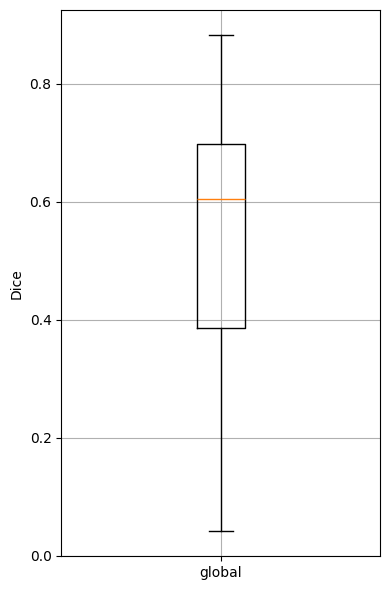

/tmp/ipykernel_1789060/3449008032.py:116: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(class_data, labels=labels)


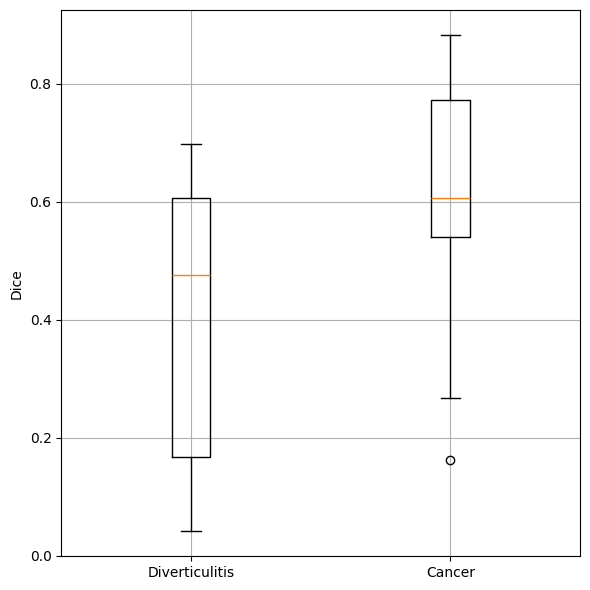

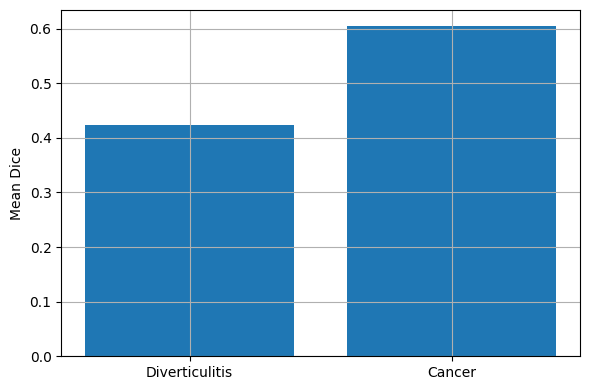

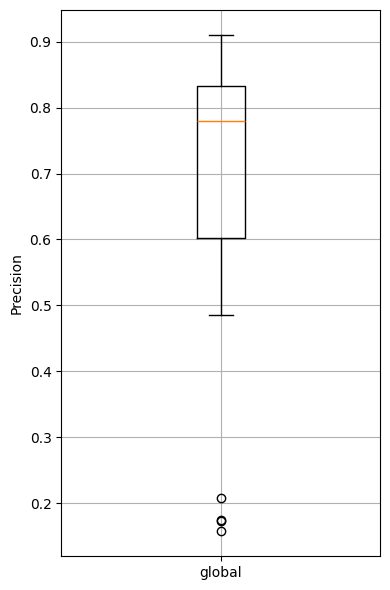

/tmp/ipykernel_1789060/3449008032.py:116: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(class_data, labels=labels)


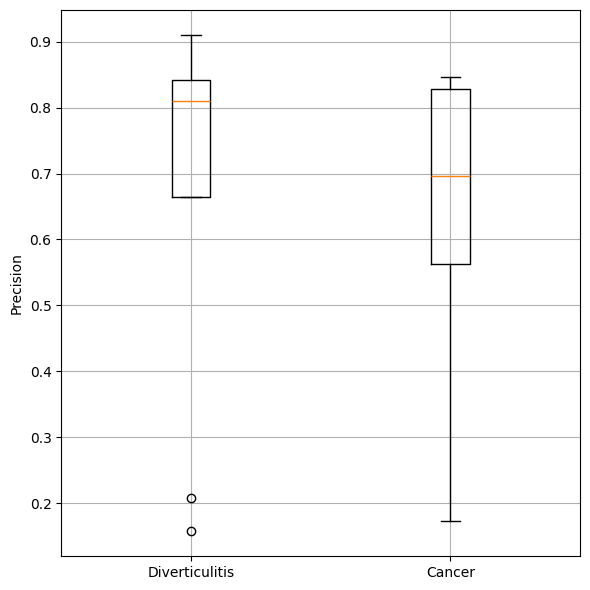

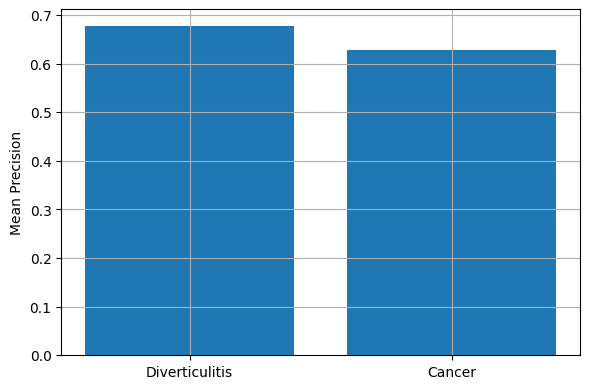

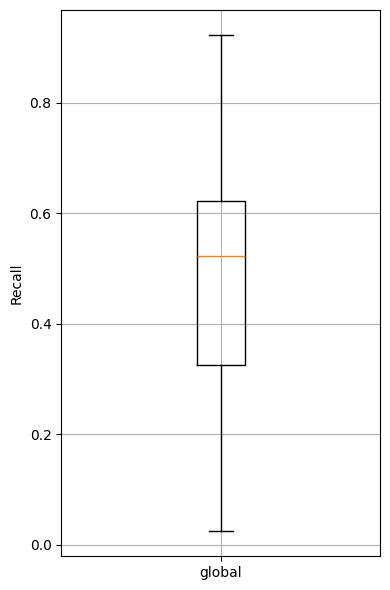

/tmp/ipykernel_1789060/3449008032.py:116: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(class_data, labels=labels)


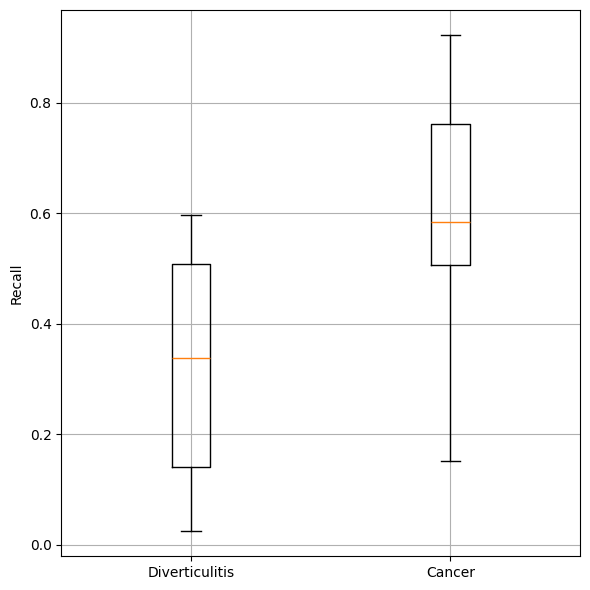

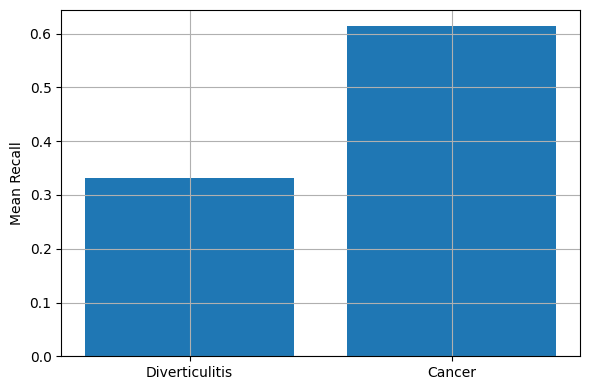

In [15]:
###############################################
# Metrics statistics & distribution plots
# (BEFORE only: Dice, Precision, Recall)
###############################################

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =============================
# Paths (EDIT THESE)
# =============================
json_path = Path(
    "/data/benchaaben/ColonCancerDetection/debug_notebooks/metrics_results_postprocessing_largest_ts.json"
)
class_csv = Path(
    "/data/colon_cancer/CC_Detection/raw_data/Dataset100_CC/labels.csv"
)

# =============================
# Load JSON
# =============================
with open(json_path, "r") as f:
    results = json.load(f)

per_case = results["per_case"]

# =============================
# Build DataFrame (BEFORE only)
# =============================
rows = []
for uid, v in per_case.items():
    rows.append({
        "uid": str(uid),
        "dice": v["before"]["dice"],
        "precision": v["before"]["precision"],
        "recall": v["before"]["recall"],
    })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} cases")

# =============================
# Load UID → class mapping
# =============================
class_df = pd.read_csv(class_csv)
class_df["UID"] = class_df["UID"].astype(str)

df = df.merge(class_df, left_on="uid", right_on="UID", how="left")
df = df.drop(columns=["UID"])

print("\nClass distribution:")
print(df["target"].value_counts())

# =============================
# Statistics helpers
# =============================
def compute_stats(values):
    values = np.asarray(values)
    return {
        "N": len(values),
        "mean": np.mean(values),
        "median": np.median(values),
        "q1": np.percentile(values, 25),
        "q3": np.percentile(values, 75),
        "min": np.min(values),
        "max": np.max(values),
    }

def print_stats(name, values):
    s = compute_stats(values)
    print(f"\n=== {name} ===")
    print(f"N      : {s['N']}")
    print(f"Mean   : {s['mean']:.3f}")
    print(f"Median : {s['median']:.3f}")
    print(f"Q1/Q3  : {s['q1']:.3f} / {s['q3']:.3f}")
    print(f"Min/Max: {s['min']:.3f} / {s['max']:.3f}")

# =============================
# Print statistics
# =============================
for metric in ["dice", "precision", "recall"]:
    print_stats(f"Global {metric.capitalize()}", df[metric])

    for cls in sorted(df["target"].dropna().unique()):
        vals = df[df["target"] == cls][metric]
        print_stats(f"Class {cls} — {metric.capitalize()}", vals)

# =============================
# Plotting helper
# =============================
def plot_metric(metric, ylabel):
    class_map = {
        0: "Diverticulitis",
        1: "Cancer",
    }

    classes = [c for c in class_map if c in df["target"].unique()]
    labels = [class_map[c] for c in classes]

    # ---------- Plot 1: Aggregated ----------
    plt.figure(figsize=(4, 6))
    plt.boxplot(df[metric], vert=True)
    plt.xticks([1], ["global"])
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---------- Plot 2: By class ----------
    class_data = [df[df["target"] == c][metric] for c in classes]

    plt.figure(figsize=(6, 6))
    plt.boxplot(class_data, labels=labels)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---------- Plot 3: Mean per class ----------
    means = [df[df["target"] == c][metric].mean() for c in classes]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, means)
    plt.ylabel(f"Mean {ylabel}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# =============================
# Generate plots
# =============================
plot_metric("dice", "Dice")
plot_metric("precision", "Precision")
plot_metric("recall", "Recall")
